# Matplotlib 미니퀘스트

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 정형 데이터

### 고유 명사
- 정형 데이터: 표나 데이터베이스처럼 행과 열의 구조를 가진 체계적인 데이터
    - 정형: 미리 정의된 구조나 스키마에 따라 체계적으로 조직되어 있음
    - 데이터: 임의의 형태로 형식화된 사실이나 개념, 의사, 명령 등을 사람이나 기계에 의한 처리가 적합하도록 문자, 기호 등으로 나타낸 것

- 스키마(Schema)가 뭐예요?
    - 데이터의 구조와 형식을 정의하는 청사진

### 사용 방법

1. 호출
    - CSV 파일 호출: `pd.read_csv('data.csv')`
    - Excel 파일 호출: `pd.read_excel('data.xlsx')`
    - SQL DB에서 호출:
        - (DB 연결) `sqlite3.connect('data.db')`
        - (DB 읽기) `pd.read_sql("SELECT * FROM table_name", conn)`
2. 탐색 및 구조 확인
    - 데이터프레임 정보: `info()`
    - 상위 5개 행: `head()`
    - 하위 5개 행: `tail()`
    - 수치형 데이터 요약 통계량: `describe()`
    - 컬럼 목록: `columns()`
3. 필터링 및 변환
    - 특정 열 선택: `df[['name', 'age', 'job']]`
    - 조건 필터링: `df[df['age'] >= 30]`
    - 새로운 열 추가: `df['salary_won'] = df['salary'] * 10000`
4. 정리 및 가공
    - 결측치 처리: `df.fillna('no_exist', inplace=True)`, `df.dropna(inplace=True)`
    - 중복값 처리: `df.drop_duplicates(inplace=True)`
    - 타입 변환:
        - (문자열 -> 날짜) `df['subscribed_date'] = pd.to_datetime(df['subscribed_date'])`
        - (실수형 -> 정수형) `df['salary'] = df['salary'].astype(int)`
5. 정렬 및 그룹화
    - 오름차순 정렬: `df.sort_values(by='salary')`
    - 오름차순 정렬: `df.sort_values(by='salary', ascending=False)`
    - 평균 계산: `df.groupby('department')['salary'].mean()`
6. 저장
    - CSV 파일 저장: `df.to_csv("processed_data.csv", index=False)`
    - Excel 파일 저장: `df.to_excel("processed_data.xlsx", index=False)`
    - SQL DB에 저장: `df.to_sql("processed_table", conn, if_exists='replace', index=False)`

In [3]:
# 1번 퀘스트
# 샘플 데이터프레임을 생성한 후, 데이터의 기본 정보를 출력하기
data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동'],
    '나이': [25, 30, 35, 28, 40],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO'],
    '연봉': [4000, 3500, 5000, 4200, 10000],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27']
}
df = pd.DataFrame(data)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   이름      5 non-null      object
 1   나이      5 non-null      int64 
 2   직업      5 non-null      object
 3   연봉      5 non-null      int64 
 4   가입일     5 non-null      object
dtypes: int64(2), object(3)
memory usage: 328.0+ bytes
None


In [4]:
# 2번 퀘스트
# 샘플 데이터에서 나이가 30 이상이고 연봉이 5000 이하인 사람만 필터링하기
data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동', '정지훈', '이지은'],
    '나이': [25, 30, 35, 28, 40, 50, 22],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO', '디자이너', '마케터'],
    '연봉': [4000, 3500, 5000, 4200, 10000, 4600, 3300],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27', '2016-04-11', '2022-03-19']
}
df = pd.DataFrame(data)
filtered = df[(df['나이'] >= 30) & (df['연봉'] <= 5000)]
print(filtered)


    이름  나이    직업    연봉         가입일
1  이영희  30   마케터  3500  2019-07-15
2  박민수  35   개발자  5000  2021-01-10
5  정지훈  50  디자이너  4600  2016-04-11


In [10]:
# 3번 퀘스트
# 샘플 데이터에서 가입 연도가 2019년 이전인 사람들을 찾아 연봉을 10% 인상한 후, 전체 평균 연봉을 계산하기
data = {
    '이름': ['김철수', '이영희', '박민수', '최지현', '홍길동', '정지훈', '이지은'],
    '나이': [25, 30, 35, 28, 40, 50, 22],
    '직업': ['개발자', '마케터', '개발자', '디자이너', 'CEO', '디자이너', '마케터'],
    '연봉': [4000, 3500, 5000, 4200, 10000, 4600, 3300],
    '가입일': ['2020-05-21', '2019-07-15', '2021-01-10', '2018-11-03', '2017-09-27', '2016-04-11', '2022-03-19']
}
df = pd.DataFrame(data)
df['가입일'] = pd.to_datetime(df['가입일'])
before_2019 = df['가입일'] < pd.to_datetime("2019-01-01")
df['연봉'] = df['연봉'].where(~before_2019, df['연봉'] * 1.1)
average_salary = df['연봉'].mean()
print(average_salary)


5211.428571428572


/var/folders/4l/dzqs3mjj63z60y274kj7flcr0000gn/T/ipykernel_19674/3665893711.py:13: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['연봉'] = df['연봉'].where(~before_2019, df['연봉'] * 1.1)


## 비정형 데이터

### 고유 명사
- 비정형 데이터: 고정된 구조 없이 텍스트, 이미지, 영상, 오디오 등 다양한 형식으로 존재하는 데이터

- 고정된 스키마가 없어 일정한 규칙으로 정리되지 않음.
- 데이터베이스의 관계형 테이블과 같은 체계적인 저장 방식이 아닌 **파일 시스템, 클라우드 스토리지, NoSQL 데이터베이스** 등에 저장되는 경우가 많음.

- 반정형 데이터: 정형 데이터처럼 일부 구조를 가지지만, 고정된 스키마 없이 유동적으로 저장되는 데이터
    - 일반적으로 태그, 키-값 쌍 등의 형식으로 구성
    - 엄격한 구조는 없지만 특정 규칙을 따름
    - JSON, XML, YAML, 로그 파일 등
    - 데이터 저장과 분석에 유연성 제공

### 사용 방법
- 수집 &rarr; 전처리 &rarr; 변환 &rarr; 분석 &rarr; 저장 과정을 거쳐 사용

1. 데이터 수집
    - 웹 크롤링 예시(웹 사이트에서 텍스트 데이터 수집 및 추출):
        ```python
        import requests
        from bs4 import BeautifulSoup

        # 수집
        response = requests.get("https://example.com")
        soup = BeautifulSoup(response.text, "html.parser")

        # 추출
        text_data = soup.get_text()
        print(text_data[:500])
        ```
    - API 예시(공공/소셜 데이터 API 수집 예시):
        ```python
        import requests

        # 공공데이터 API에서 JSON 데이터 가져오기
        api_url = "https://jsonplaceholder.typicode.com/posts"
        response = requests.get(api_url)

        # JSON 데이터 변환
        data = response.json()

        # 첫 3개 게시글 출력
        for post in data[:3]:
            print(f"제목: {post['title']}\n내용: {post['body']}\n")
        ```
    - 텍스트 파일 예시(텍스트 파일에서 텍스트 데이터 수집 예시):
        ```python
        # 파일을 읽기 모드로 열기
        with open("sample_text.txt", "r", encoding="utf-8") as file:
            text_data = file.read() # 파일 전체 내용을 문자열로 읽기
        
        print(text_data[:500])
        ```
    - CSV 파일 예시(CSV 파일에서 데이터 수집 예시):
        ```python
        import pandas as pd

        # CSV 파일 읽기
        df = pd.read_csv("sample_data.csv")

        print(df.head())
        ```
    - 이미지 파일 예시(이미지 파일에서 데이터 수집 예시):
        ```python
        from PIL import Image
        import numpy as np

        # 이미지 불러오기
        image = Image.open("example.jpg")

        # NumPy 배열로 변환
        image_array = np.array(image)

        # 이미지 크기 출력
        print(image_array.shape) # (높이, 너비, 채널 수)
        ```

2. 🚧 데이터 전처리
    - 예시(텍스트 데이터 정제):
        ```python
        ```
    - 예시(이미지 데이터 전처리):
        ```python
        ```

3. 🚧 데이터 변환 (정형 데이터로)
    - 예시(텍스트 데이터를 정형 데이터로 변환, 토큰화 및 감성 분석):
        ```python
        ```
    - 예시(이미지 데이터를 정형 데이터로 변환, 특징 벡터 추출):
        ```python
        ```

4. 🚧 데이터 분석
    - 예시(텍스트 데이터 빈도 분석):
        ```python
        ```
    - 예시(이미지 데이터 색상 분석):
        ```python
        ```

5. 데이터 저장 및 호출
    - 예시(CSV 저장 및 호출):
        ```python
        # CSV 파일 저장 (감성 분석 데이터 저장)
        df.to_csv("sentiment_analysis.csv", index=False)

        # CSV 파일 호출
        df_loaded = pd.read_csv("sentiment_analysis.csv")
        print(df_loaded.head())
        ```
    - 예시(이미지 데이터 저장 및 호출):
        ```python
        from PIL import Image
        
        # 이미지 저장 (가정: 리사이징 후 저장)
        resized_image = Image.open(image_path).resize((100, 200))
        resized_image.save("resized_image.jpg")

        # 이미지 호출
        loaded_image = Image.open("resized_image.jpg")
        loaded_image.show()
        ```

In [21]:
# 1번 퀘스트
# JSON 형식 데이터를 직접 생성한 후, Pandas 데이터프레임으로 변환하기
from io import StringIO
data = '''
[
    {"이름": "김철수", "나이": 25, "직업": "개발자", "연봉": 4000},
    {"이름": "이영희", "나이": 30, "직업": "마케터", "연봉": 3500},
    {"이름": "박민수", "나이": 35, "직업": "디자이너", "연봉": 4200}
]
'''
df = pd.read_json(StringIO(data))
"""
    # 참고사항
    pd.read_json은 원래 파일 경로, URL을 받도록 설계된 함수
    최근 pandas에서 문자열(JSON literal)을 직접 넣는 방식이 deprecated 되었고,
    이제 StringIO로 감싸서 문자열임을 명시해줘야 함.
"""
print(df)

    이름  나이    직업    연봉
0  김철수  25   개발자  4000
1  이영희  30   마케터  3500
2  박민수  35  디자이너  4200


In [33]:
# 2번 퀘스트
# 아래 샘플 데이터에서 한글과 공백을 제외한 모든 문자를 제거하고
# 공백을 하나로 정리하기
import re

text = "안녕하세요!!! 저는 AI 모델-입니다. 12345 데이터를   정리해 보겠습니다."
clean_text = re.sub(r"[^가-힣\s]", "", text)
clean_text = re.sub(r"\s+", " ", clean_text).strip()
print(clean_text)

안녕하세요 저는 모델입니다 데이터를 정리해 보겠습니다


In [40]:
# 3번 퀘스트
# 주어진 텍스트 데이터를 문장 단위로 분리한 후
# 각 문장의 단어 개수를 데이터프레임으로 변환하기
text = "자연어 처리는 재미있다. 파이썬과 pandas를 활용하면 편리하다. 데이터 분석은 흥미롭다."
sentences = text.split('. ')
word_counts = [len(sentence.split()) for sentence in sentences]
df = pd.DataFrame({
    '문장': sentences,
    '단어_개수': word_counts
})
print(df)

                       문장  단어_개수
0            자연어 처리는 재미있다      3
1  파이썬과 pandas를 활용하면 편리하다      4
2           데이터 분석은 흥미롭다.      3


## 막대 그래프(Bar chart)

<BarContainer object of 5 artists>

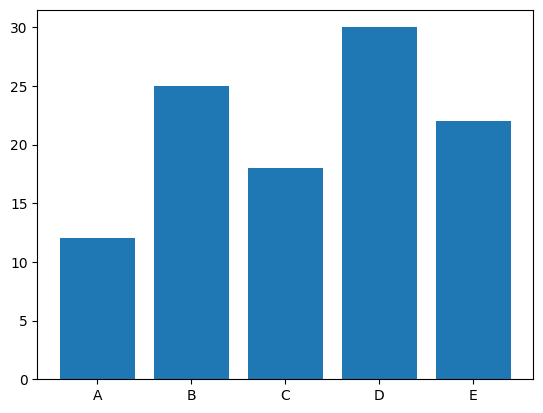

In [43]:
# 1번 퀘스트
# matplotlib을 활용하여
# 5개의 카테고리와 각각의 값이 포함된 기본 세로 막대 그래프 생성하기
categories = ['A', 'B', 'C', 'D', 'E']
values = [12, 25, 18, 30, 22]

plt.bar(categories, values)

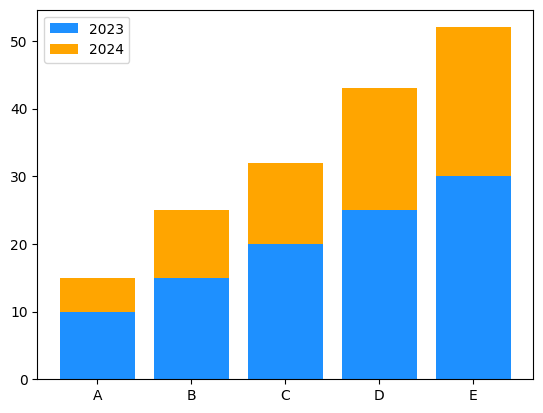

In [ ]:
# 2번 퀘스트
# 누적형 막대 그래프를 생성하여
# 두 개의 연도별 데이터를 각각 다른 색상으로 누적하여 표현하기
categories = ['A', 'B', 'C', 'D', 'E']
values_2023 = [10, 15, 20, 25, 30]
values_2024 = [5, 10, 12, 18, 22]

x = np.arange(len(categories))
plt.xticks(x, categories)
plt.bar(x, values_2023, color='dodgerblue', label='2023')
plt.bar(x, values_2024, color='orange', bottom=values_2023, label='2024') 

plt.legend()

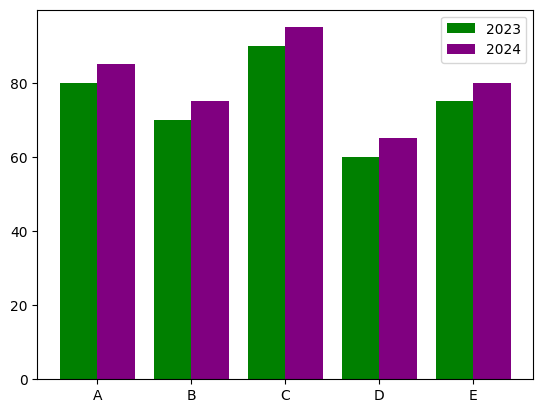

In [51]:
# 3번 퀘스트
# 한 기업의 부서별 연간 성과(2023년 vs 2024년)를 비교하는
# 그룹형 막대 그래프를 생성하기
departments = ['Sales', 'Marketing', 'IT', 'HR', 'Finance']
performance_2023 = [80, 70, 90, 60, 75]
performance_2024 = [85, 75, 95, 65, 80]

bar_width = 0.4
x = np.arange(len(departments))
plt.xticks(x, categories)
plt.bar(x - bar_width/2, performance_2023, width=bar_width, color='green', label='2023')
plt.bar(x + bar_width/2, performance_2024, width=bar_width, color='purple', label='2024')

plt.legend()

## 히스토그램(Histogram)

(array([  5.,   9.,  19.,  53.,  85., 121., 152., 150., 138., 134.,  68.,
         33.,  21.,   9.,   3.]),
 array([-3.02140577, -2.61426291, -2.20712006, -1.7999772 , -1.39283435,
        -0.98569149, -0.57854864, -0.17140579,  0.23573707,  0.64287992,
         1.05002278,  1.45716563,  1.86430849,  2.27145134,  2.6785942 ,
         3.08573705]),
 <BarContainer object of 15 artists>)

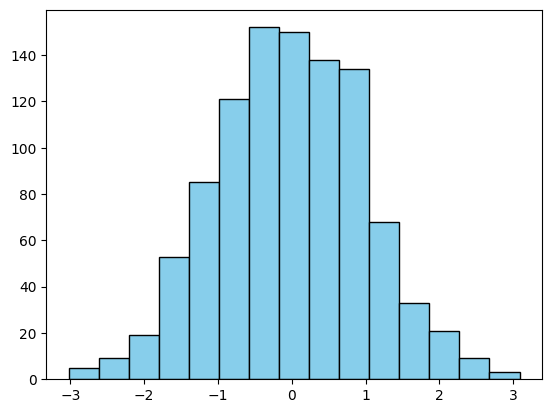

In [52]:
# 1번 퀘스트
# 정규 분포를 따르는 1000개의 데이터를 생성한 후,
# 구간을 15개로 설정한 히스토그램을 그리기
data = np.random.randn(1000)

plt.hist(data, bins=15, color='skyblue', edgecolor='black') 

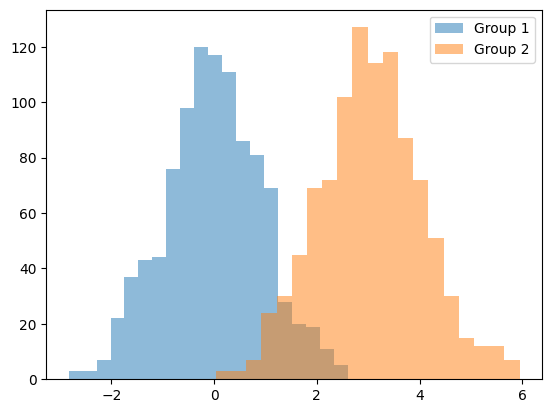

In [55]:
# 2번 퀘스트
# 두 개의 서로 다른 정규 분포를 따르는 데이터셋을 생성한 후,
# 두 히스토그램을 같은 그래프에서 겹쳐서 비교하기
data1 = np.random.randn(1000) # 첫 번째 데이터셋 (평균 0, 표준편차 1)
data2 = np.random.randn(1000) + 3 # 두 번째 데이터셋 (평균 3, 표준편차 1)

plt.hist(data1, bins=20, alpha=0.5, label='Group 1')
plt.hist(data2, bins=20, alpha=0.5, label='Group 2')
plt.legend()

Text(0, 0.5, 'Cumulative Frequency')

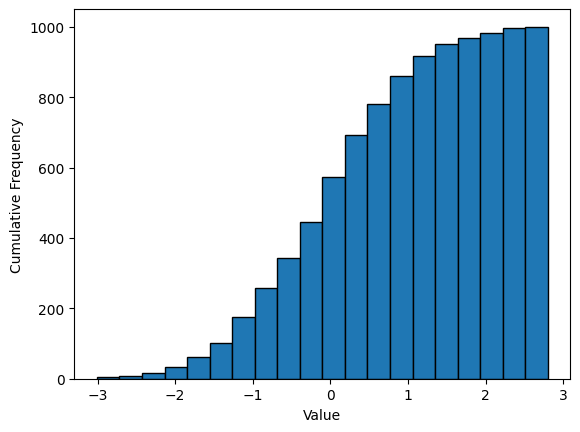

In [59]:
# 3번 퀘스트
# 한 데이터셋의 누적 히스토그램을 그린 후,
# X축과 Y축의 적절한 레이블을 설정하기
data = np.random.randn(1000)

plt.hist(data, bins=20, cumulative=True, edgecolor="black")
plt.xlabel("Value")
plt.ylabel("Cumulative Frequency")

## 산점도(Scatter Plot)

Text(0, 0.5, 'Y-axis')

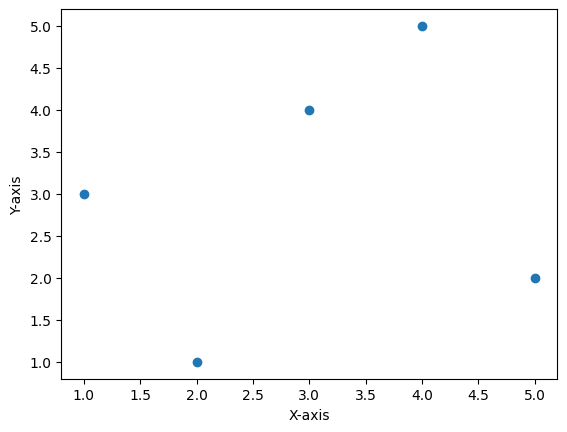

In [ ]:
# 1번 퀘스트
# 두 개의 리스트를 사용하여 산점도를 그리고,
# X축과 Y축의 라벨을 추가하기
x = [1, 2, 3, 4, 5]
y = [3, 1, 4, 5, 2]

plt.scatter(x, y)
plt.xlabel("X-axis")
plt.ylabel("Y-axis")

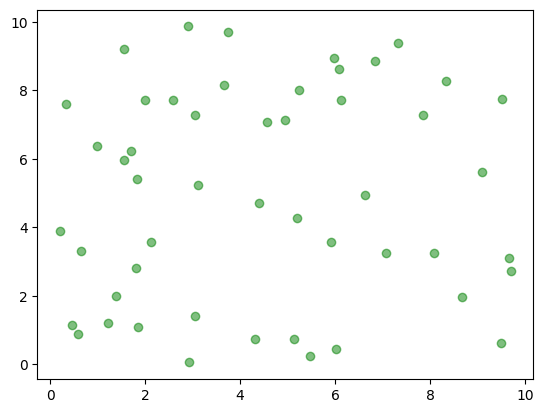

In [70]:
# 2번 퀘스트
# 난수를 생성한 후,
# 산점도를 그리고 점의 색상과 투명도를 설정하기
np.random.seed(42)
x = np.random.rand(50) * 10  # 0~10 범위의 난수 50개
y = np.random.rand(50) * 10  # 0~10 범위의 난수 50개

plt.scatter(x, y, color='green', alpha=0.5)    

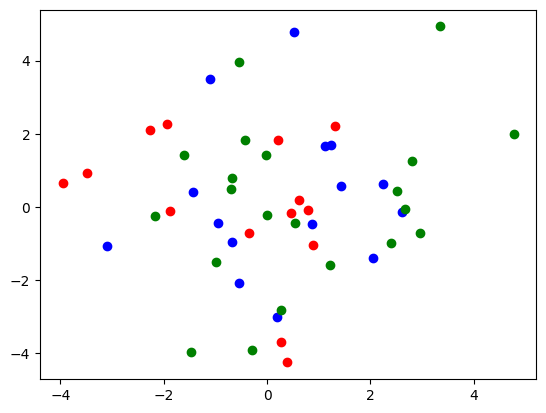

In [71]:
# 3번 퀘스트
# 세 개의 그룹('A', 'B', 'C')에 속하는 데이터의 산점도를
# 서로 다른 색상으로 그리기
np.random.seed(10)
x = np.random.randn(50) * 2
y = np.random.randn(50) * 2
categories = np.random.choice(['A', 'B', 'C'], size=50)

colors = {'A': 'red', 'B': 'blue', 'C': 'green'}

for category in np.unique(categories):
    index = category == categories
    plt.scatter(x[index], y[index], color=colors[category])

## 박스플롯(Box Plot)

### 고유 명사
- Box Plot: 데이터의 분포, 중앙값, 사분위수, 이상치를 시각적으로 나타내는 시각화 방법

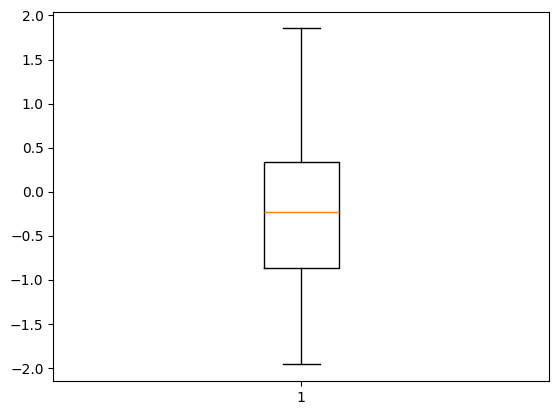

In [73]:
# 1번 퀘스트
# 평균 0, 표준편차 1을 따르는 정규분포 난수 50개를 생성한 후,
# 해당 데이터를 이용해 기본 박스 플롯을 출력하기
np.random.seed(42)
data = np.random.randn(50)

plt.boxplot(data)
plt.show()

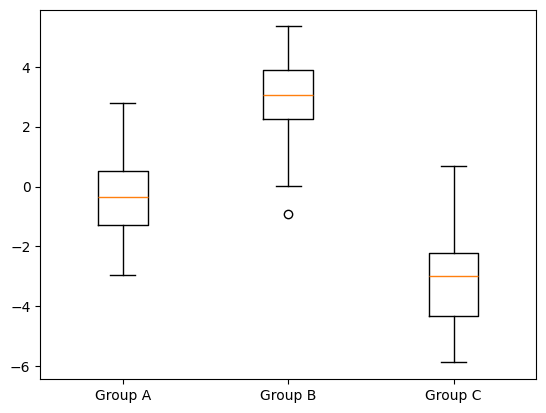

In [77]:
# 2번 퀘스트
# 세 개의 그룹(Group A, Group B, Group C) 에 대해
# 각 다른 평균을 가지는 데이터를 생성하고,
# 이를 이용해 다중 박스 플롯을 그리기
np.random.seed(42)
group_a = np.random.randn(50) * 1.5  # 표준편차 1.5, 평균 0
group_b = np.random.randn(50) * 1.5 + 3  # 표준편차 1.5, 평균 3
group_c = np.random.randn(50) * 1.5 - 3  # 표준편차 1.5, 평균 -3

plt.boxplot([group_a, group_b, group_c], tick_labels=['Group A', 'Group B', 'Group C'])
plt.show()

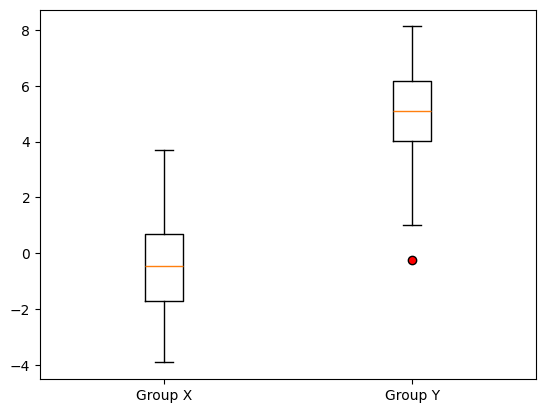

In [85]:
# 3번 퀘스트
# 평균이 서로 다른 두 개의 그룹을 비교하는 박스 플롯을 그리기
# 단, 이상값을 강조하고, 스타일을 커스터마이징해야 함.
np.random.seed(42)
group_x = np.random.randn(50) * 2  # 표준편차 2, 평균 0
group_y = np.random.randn(50) * 2 + 5  # 표준편차 2, 평균 5

plt.boxplot([group_x, group_y], flierprops=dict(markerfacecolor='red', linestyle='none'), tick_labels=['Group X', 'Group Y'])
plt.show()

## 고급 다중 그래프(Advanced Multiple Graphs)

### 고유 명사
- 하나의 Figure 내에서 여러 개의 그래프를 배치하여 다양한 데이터 관계를 동시에 시각화하는 기법

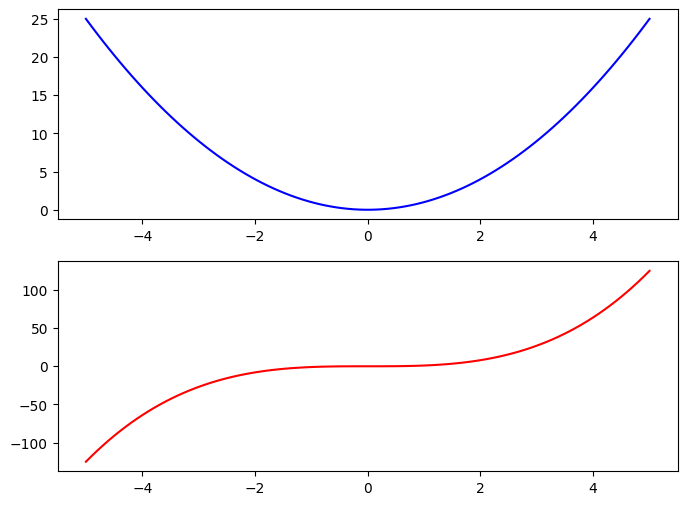

In [ ]:
# 1번 퀘스트
# 2x1 형태의 서브플롯을 만들고,
# 첫 번째 서브플롯에는 y = x^2
# 두 번째 서브플롯에는 y = x^3을 그리기
x = np.linspace(-5, 5, 100)
y1 = x ** 2  # x의 제곱
y2 = x ** 3  # x의 세제곱

# Setting Subplot (2x1 Matrix)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 6))

# First Subplot
axes[0].plot(x, y1, color='b', label='x^2')

# Second Subplot
axes[1].plot(x, y2, color='r', label='x^3')

plt.show()

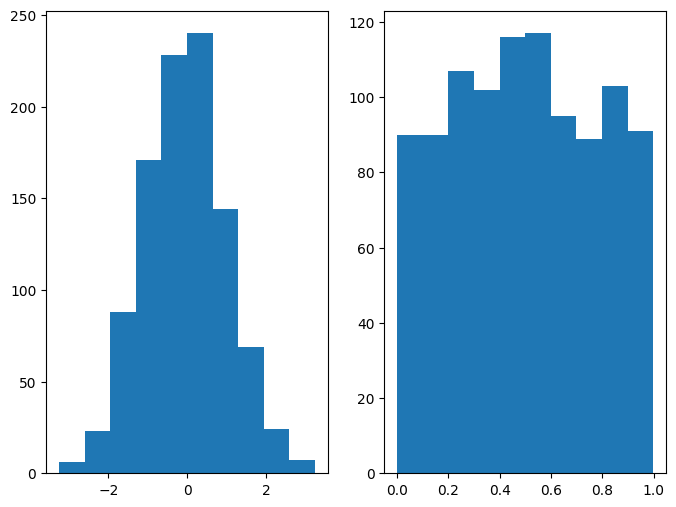

In [92]:
# 2번 퀘스트
# X축을 공유하는 1행 2열 형태의 서브플롯을 생성하고,
# 첫 번째 서브플롯에는 정규 분포를 따르는 난수의 히스토그램,
# 두 번째 서브플롯에는 균등 분포를 따르는 난수의 히스토그램을 그리기
normal_data = np.random.randn(1000)  # 정규 분포 난수 1000개
uniform_data = np.random.rand(1000)  # 균등 분포 난수 1000개

# Setting Subplot (1x2 Matrix)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 6))

# First Subplot
axes[0].hist(normal_data)

# Second Subplot
axes[1].hist(uniform_data)

plt.show()

[0 1 2 3 4]


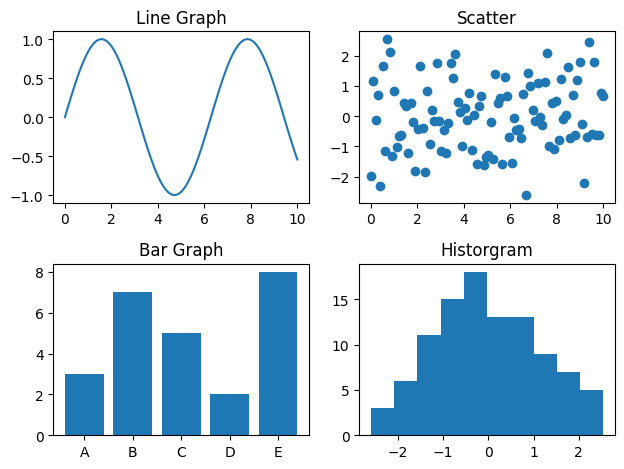

In [103]:
# 3번 퀘스트
# 불규칙한 레이아웃의 서브플롯을 생성하고,
# 각각 선 그래프, 산점도, 막대 그래프, 히스토그램을 그리기
x = np.linspace(0, 10, 100)
line_data = np.sin(x)
bar_data = [3, 7, 5, 2, 8]
hist_data = np.random.randn(100)
categories = ['A', 'B', 'C', 'D', 'E']

fig, axes = plt.subplots(nrows=2, ncols=2)

# Line Graph
axes[0, 0].plot(x, line_data)
axes[0, 0].set_title("Line Graph")

# Scatter
axes[0, 1].scatter(x, hist_data)
axes[0, 1].set_title("Scatter")

# Bar Graph
print(np.arange(5))
axes[1, 0].bar(categories, bar_data)
axes[1, 0].set_title("Bar Graph")

# Histogram
axes[1, 1].hist(hist_data)
axes[1, 1].set_title("Historgram")

plt.tight_layout()
plt.show()

## 벤 다이어그램(Venn diagram)

In [116]:
from matplotlib_venn import venn2, venn3

{'포도', '수박', '체리', '사과'}


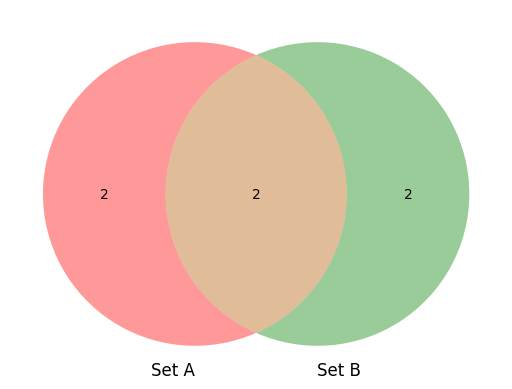

In [ ]:
# 1번 퀘스트
# 두 개의 과일 집합을 정의하고,
# 두 집합의 차집합(한 집합에만 존재하는 요소)을 출력하기
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}

symmetric_diff = set_A.symmetric_difference(set_B)
print(symmetric_diff)
venn2((set_A, set_B), set_labels=("Set A", "Set B"))
plt.show()

Only A: 2개 -> {'체리', '사과'}
Only B: 1개 -> {'포도'}
Only C: 2개 -> {'오렌지', '딸기'}
A and B: 1개 -> {'바나나'}
A and C: 0개 -> set()
B and C: 1개 -> {'수박'}
A and B and C: 1개 -> {'망고'}


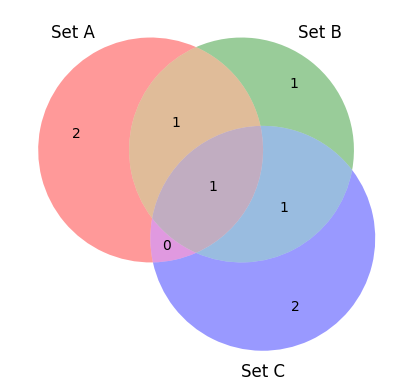

In [121]:
# 2번 퀘스트
# 벤 다이어그램을 그리지 않고, 세 개의 집합을 비교하여
# 각 집합이 단독으로 가지는 요소 개수와 교집합 개수를 계산하기
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}
set_C = {"망고", "수박", "딸기", "오렌지"}

# 1. 차집합 개수 (각 집합이 단독으로 가지는 요소 개수)
only_A = set_A - set_B - set_C
only_B = set_B - set_A - set_C
only_C = set_C - set_A - set_B

# 2. 교집합 개수
A_and_B_only = (set_A & set_B) - set_C
A_and_C_only = (set_A & set_C) - set_B
B_and_C_only = (set_B & set_C) - set_A
A_and_B_and_C = set_A & set_B & set_C

print(f"Only A: {len(only_A)}개 -> {only_A}")
print(f"Only B: {len(only_B)}개 -> {only_B}")
print(f"Only C: {len(only_C)}개 -> {only_C}")

print(f"A and B: {len(A_and_B_only)}개 -> {A_and_B_only}")
print(f"A and C: {len(A_and_C_only)}개 -> {A_and_C_only}")
print(f"B and C: {len(B_and_C_only)}개 -> {B_and_C_only}")
print(f"A and B and C: {len(A_and_B_and_C)}개 -> {A_and_B_and_C}")

venn3((set_A, set_B, set_C), set_labels=("Set A", "Set B", "Set C"))
plt.show()

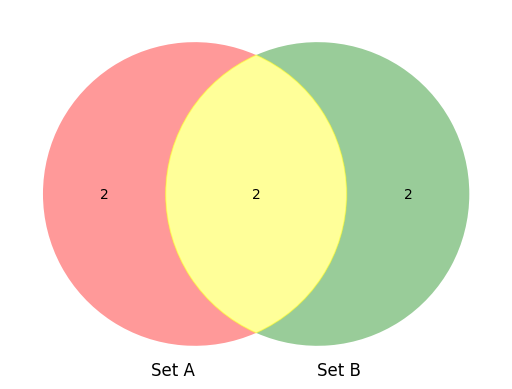

In [131]:
# 3번 퀘스트
# 벤 다이어그램을 그리면서,
# 특정 조건을 만족하는 경우 색상을 다르게 지정하기
# 조건: 교집합이 2개 이상이면 노란색, 그렇지 않으면 기본 색상을 사용하기
set_A = {"사과", "바나나", "체리", "망고"}
set_B = {"바나나", "망고", "포도", "수박"}

venn = venn2((set_A, set_B), set_labels=("Set A", "Set B"))

# 교집합의 개수
intersection_size = len(set_A & set_B)

if intersection_size >= 2:
    venn.get_patch_by_id('11').set_color('yellow')

plt.show()

## 범주형 데이터(Categorical Data)

### 고유 명사
- 정해진 그룹이나 레이블을 가지는 데이터

In [133]:
import seaborn as sns

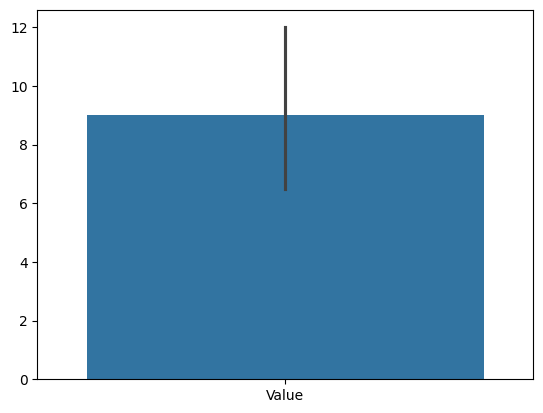

In [142]:
# 1번 퀘스트
# Seaborn을 활용하여 막대 그래프(bar plot)를 생성하기
data = pd.DataFrame({
    "Category": ["X", "X", "Y", "Y", "Z", "Z", "Z", "X", "Y", "Z"],
    "Value": [5, 9, 4, 6, 12, 10, 14, 7, 5, 18]
})
sns.barplot(data)
plt.show()

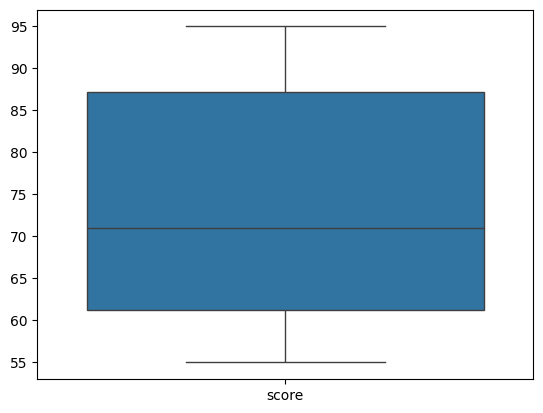

In [143]:
# 2번 퀘스트
# 범주형 데이터의 분포를 시각화하기 (boxplot)
data = pd.DataFrame({
    "group": ["A", "A", "B", "B", "C", "C", "C", "A", "B", "C"],
    "score": [65, 70, 55, 60, 90, 85, 95, 72, 58, 88]
})
sns.boxplot(data)
plt.show()

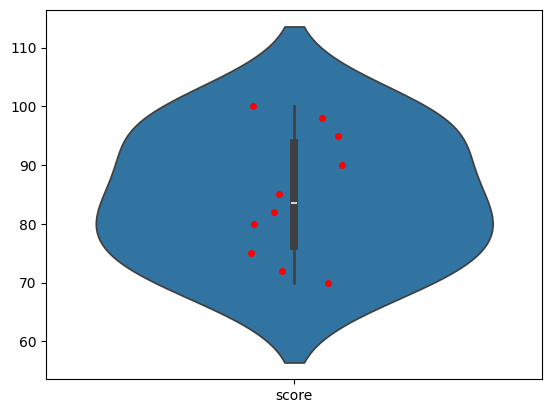

In [146]:
# 3번 퀘스트
# 범주형 데이터의 분포를 더욱 자세히 시각화하기 (violinplot, stripplot)
data = pd.DataFrame({
    "category": ["A", "A", "B", "B", "C", "C", "C", "A", "B", "C"],
    "score": [80, 85, 70, 75, 95, 90, 100, 82, 72, 98]
})
sns.violinplot(data)
sns.stripplot(data, color='r', jitter=True)
plt.show()

## 연속형 데이터(Continuous Data)

### 고유 명사
- 특정 구간 내에서 이론적으로 무한한 값을 가질 수 있는 데이터

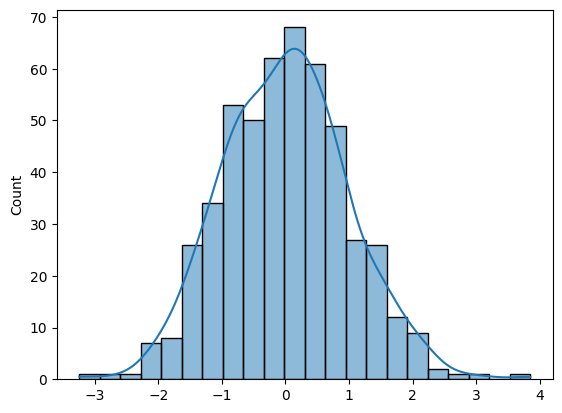

In [148]:
# 1번 퀘스트
# 평균 0, 표준편차 1을 따르는 정규 분포 데이터를 500개 생성한 후,
# 히스토그램과 KDE를 함께 시각화하기
np.random.seed(42)
data = np.random.randn(500)

sns.histplot(data, kde=True)
plt.show()

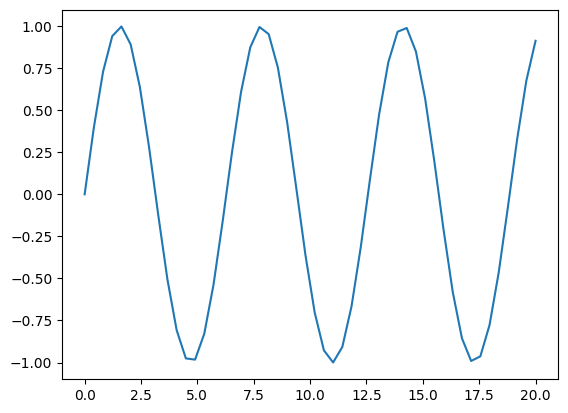

In [ ]:
# 2번 퀘스트
# 0부터 20까지 균등한 간격으로 생성된 데이터를 사용하여,
# 사인 함수의 선 그래프를 그리기
x = np.linspace(0, 20, 100)
y = np.sin(x)

sns.lineplot(x=x, y=y)
plt.show()

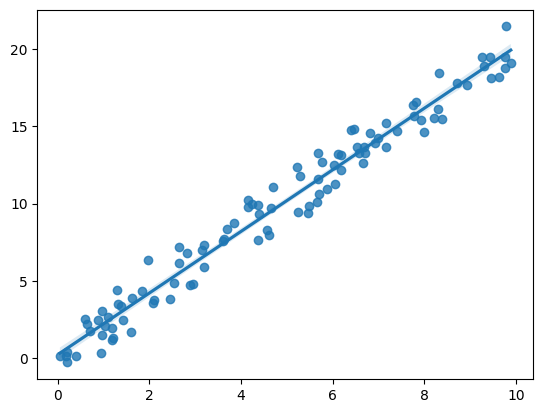

In [167]:
# 3번 퀘스트
# 랜덤한 100개의 연속형 데이터를 생성하여,
# 산점도와 회귀선을 포함한 그래프를 그리기
np.random.seed(0)
x = np.random.rand(100) * 10  # 0~10 사이 난수
y = 2 * x + np.random.randn(100)  # x와 비례하는 관계, 약간의 변동 추가

sns.regplot(x=x, y=y)
plt.show()

## 관계 데이터(Relational Data)

### 고유 명사
- 두 개 이상의 변수 간의 상관관계나 패턴을 분석하는 데이터

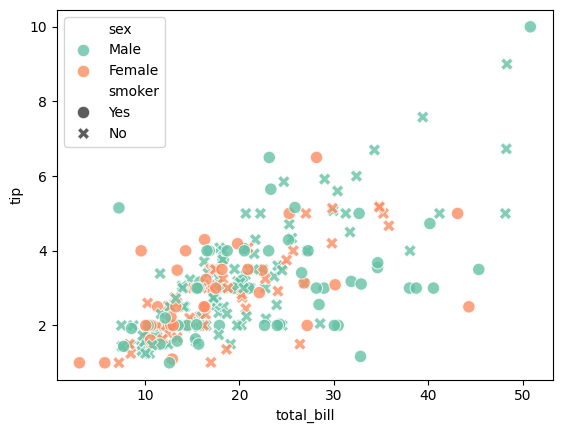

In [178]:
# 1번 퀘스트
# eaborn의 scatterplot을 활용하여
# "총 결제 금액"(total_bill)과 "팁"(tip)의 관계를 시각화하기
# 단, scatterplot의 색상과 스타일을 다르게 설정하여 출력
tips = sns.load_dataset("tips")

sns.scatterplot(data=tips, x='total_bill', y='tip',
                hue='sex', style="smoker", palette='Set2', s=80, alpha=0.8)
plt.show()

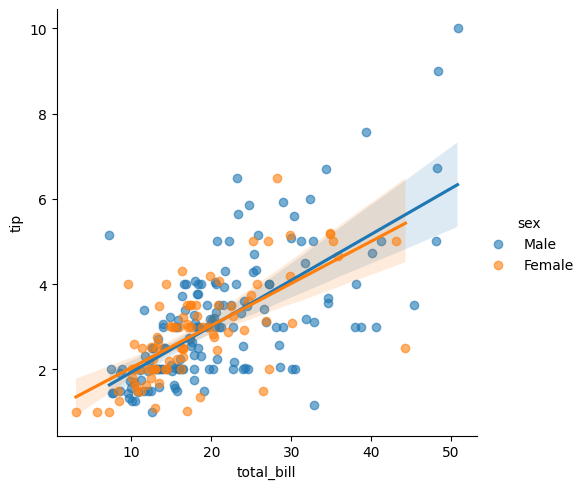

In [ ]:
# 2번 퀘스트
# sns.regplot을 사용하여
# total_bill과 tip의 관계를 나타내는 회귀선 그래프를 그리고,
# 산점도의 투명도를 조정하기
# 단, 산점도에서 특정 성별(sex)만 필터링하여 표시
tips = sns.load_dataset("tips")

# 방법 1. sns.regplot 사용하기
"""
    Regression Plot
    회귀선 + 산점도를 그리는 함수
"""
# male_tips = pd.DataFrame(tips[tips['sex'] == 'Male'])
# female_tips = pd.DataFrame(tips[tips['sex'] == 'Female'])
# sns.regplot(data=male_tips, x='total_bill', y='tip', scatter_kws={'alpha': 0.5}, label="Male")
# sns.regplot(data=female_tips, x='total_bill', y='tip', scatter_kws={'alpha': 0.5}, label="Female")
# plt.legend(title='Sex')

# 방법 2. sns.lmplot 사용하기
"""
    Linear Model Plot
    회귀선 + 산점도를 그리면서, hue(색상 구분)와 style을 쉽게 적용할 수 있음
"""
sns.lmplot(
    data=tips, 
    x='total_bill', 
    y='tip',
    hue='sex',                    
    scatter_kws={'alpha': 0.6},   
)
plt.show()

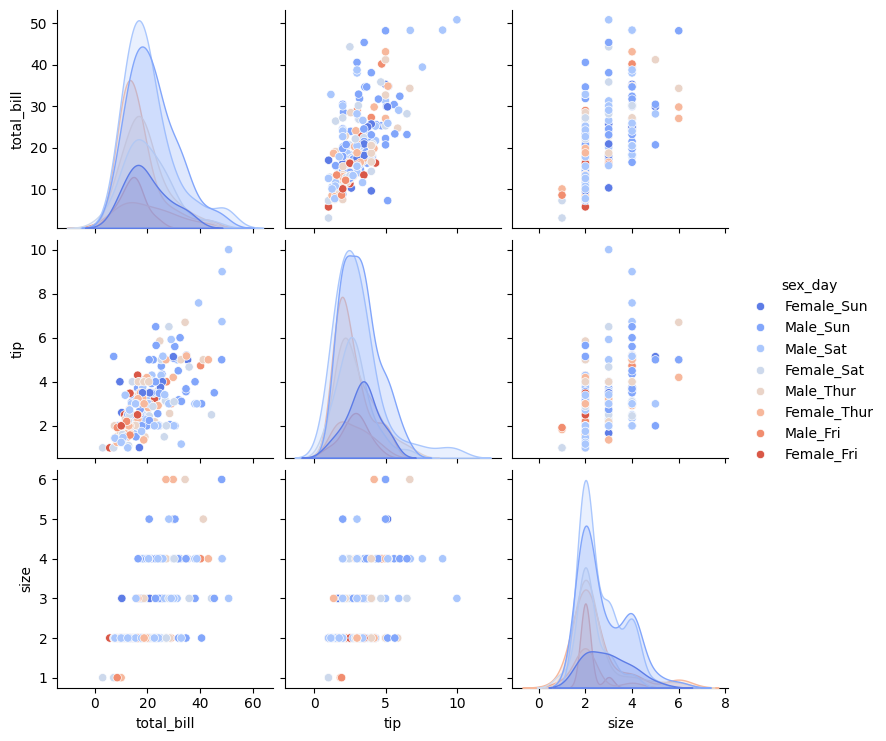

In [201]:
# 3번 퀘스트
# sns.pairplot을 사용하여 total_bill, tip, size 간의 관계를
# sex과 day에 따라 시각화하기
# 단, 요일(day)에 따라 다른 색상을 적용
tips = sns.load_dataset("tips")

tips['sex_day'] = tips['sex'].astype(str) + '_' + tips['day'].astype(str)

sns.pairplot(data=tips, vars=['total_bill', 'tip', 'size'], hue='sex_day', palette='coolwarm', diag_kind='kde')
plt.show()

## 시계열 데이터(Time Series Data)

### 고유 명사
- 시간의 흐름에 따라 일정한 간격(초, 분, 시간, 일, 월, 연 등)으로 측정된 연속적인 데이터

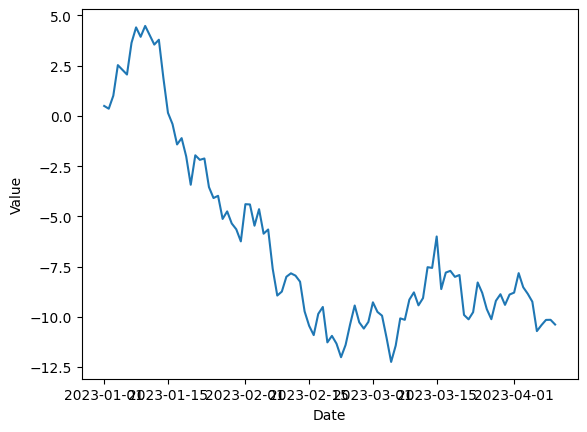

In [202]:
# 1번 퀘스트
# 100일간의 시계열 데이터를 생성하고, 이를 선 그래프로 시각화하기
np.random.seed(42)
date_range = pd.date_range(start="2023-01-01", periods=100, freq="D")  # 100일간의 날짜 생성
values = np.cumsum(np.random.randn(100))  # 랜덤 값의 누적합

df = pd.DataFrame({"Date": date_range, "Value": values})
sns.lineplot(data=df, x="Date", y="Value")
plt.show()

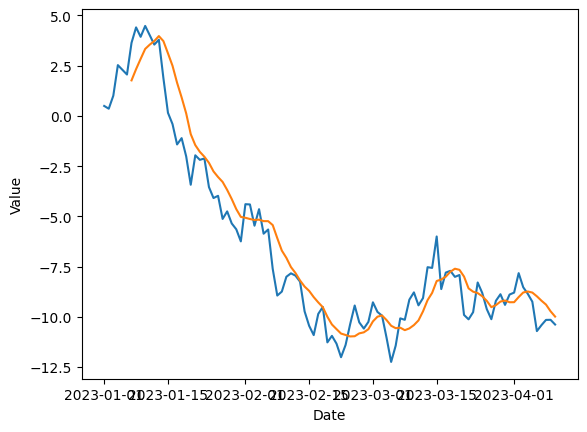

In [203]:
# 2번 퀘스트
# 1번 퀘스트에서 생성한 데이터를 기반으로
# 7일 이동 평균을 계산하고, 원본 데이터와 함께 그래프로 비교하기
np.random.seed(42)
date_range = pd.date_range(start="2023-01-01", periods=100, freq="D")
values = np.cumsum(np.random.randn(100))

df = pd.DataFrame({"Date": date_range, "Value": values})

# 7일 이동 평균 계산
df['Moving_Avg'] = df['Value'].rolling(window=7).mean()

# 그래프로 시각화
sns.lineplot(data=df, x='Date', y='Value')
sns.lineplot(data=df, x='Date', y='Moving_Avg')
plt.show()

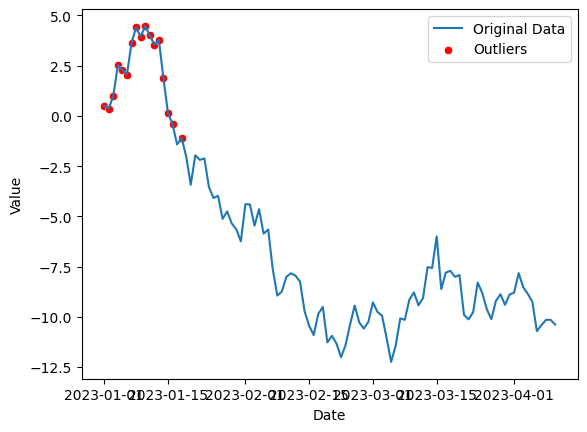

In [207]:
# 3번 퀘스트
# 1번 퀘스트에서 생성한 시계열 데이터에서
# 이상치를 탐지하고, 이상치만 강조하여 그래프에 표시하기
np.random.seed(42)
date_range = pd.date_range(start="2023-01-01", periods=100, freq="D")
values = np.cumsum(np.random.randn(100))

# 1. 사분위 범위 계산 (for 이상치 탐지)
Q1 = df['Value'].quantile(0.25)
Q3 = df['Value'].quantile(0.75)
IQR = Q3 - Q1
k = 0.5
lower_bound = Q1 - k * IQR
upper_bound = Q3 + k * IQR

# 2. 이상치 탐지
df["Outlier"] = (df["Value"] < lower_bound) | (df["Value"] > upper_bound)
outliers = pd.DataFrame(df[df["Outlier"]])

# 3. 이상치 시각화
sns.lineplot(data=df, x="Date", y="Value", label="Original Data")
sns.scatterplot(data=outliers, x="Date", y="Value", color="red", label="Outliers")
plt.legend()
plt.show()

## 리샘플링(Resampling)

### 고유 명사
- 시계열 데이터의 분석을 위해 데이터의 시간 간격을 재조정하여 다움샘플링(축소)하거나 업샘플링(확대)하는 과정

In [ ]:
# 1번 퀘스트
# pandas를 사용하여 3시간 간격의 시계열 데이터를 생성한 후,
# 하루 단위(D)로 평균을 구하는 다운샘플링을 수행하기
date_rng = pd.date_range(start="2024-01-01", end="2024-01-05", freq="3h")

# 1. 데이터프레임 생성
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(10, 100, size=len(date_rng)) # 10 ~ 100 사이 렌덤값
})

# 2. datetime을 인덱스로 설정
df.set_index("datetime", inplace=True)
print(df.head().reset_index())

# 3. 하루 단위로 다운샘플링
df_daily = df.resample("D").mean()
print(df_daily.head().reset_index())

             datetime  value
0 2024-01-01 00:00:00     85
1 2024-01-01 03:00:00     96
2 2024-01-01 06:00:00     24
3 2024-01-01 09:00:00     75
4 2024-01-01 12:00:00     41
    datetime   value
0 2024-01-01  73.000
1 2024-01-02  58.625
2 2024-01-03  62.500
3 2024-01-04  46.750
4 2024-01-05  49.000


In [ ]:
# 2번 퀘스트
# 3시간 간격으로 생성된 시계열 데이터에서
# 1시간 단위로 업샘플링한 후, 선형 보간(linear)을 적용하기
date_rng = pd.date_range(start="2024-01-01", end="2024-01-03", freq="3h")

# 1. 데이터프레임 생성
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(10, 100, size=len(date_rng)) # 10 ~ 100 사이 렌덤값
})

# 2. datetime을 인덱스로 설정
df.set_index("datetime", inplace=True)
print(df.head().reset_index())

# 3. 1시간 단위로 업샘플링
df_hourly = df.resample("h").asfreq()
print(df_hourly.head().reset_index())

# 4. 선형(linear) 보간
df_hourly_linear = df_hourly.interpolate(method="linear")
print(df_hourly_linear.head().reset_index())

             datetime  value
0 2024-01-01 00:00:00     80
1 2024-01-01 03:00:00     98
2 2024-01-01 06:00:00     54
3 2024-01-01 09:00:00     13
4 2024-01-01 12:00:00     45
             datetime  value
0 2024-01-01 00:00:00   80.0
1 2024-01-01 01:00:00    NaN
2 2024-01-01 02:00:00    NaN
3 2024-01-01 03:00:00   98.0
4 2024-01-01 04:00:00    NaN
             datetime      value
0 2024-01-01 00:00:00  80.000000
1 2024-01-01 01:00:00  86.000000
2 2024-01-01 02:00:00  92.000000
3 2024-01-01 03:00:00  98.000000
4 2024-01-01 04:00:00  83.333333


             datetime  value
0 2024-01-01 00:00:00     60
1 2024-01-01 03:00:00     28
2 2024-01-01 06:00:00     30
3 2024-01-01 09:00:00     14
4 2024-01-01 12:00:00     91
    datetime  value
0 2024-01-01     91
1 2024-01-02     99
2 2024-01-03     99
3 2024-01-04     95
4 2024-01-05     95
    datetime  value
0 2024-01-01     14
1 2024-01-02     10
2 2024-01-03     35
3 2024-01-04     35
4 2024-01-05     10


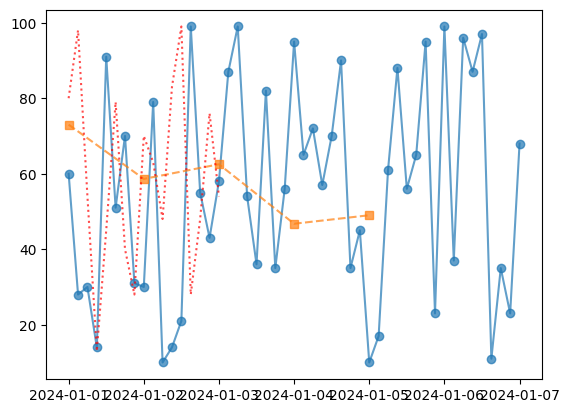

In [231]:
# 3번 퀘스트
# 3시간 간격으로 생성된 시계열 데이터에서
# 하루 단위(D)로 다운샘플링을 수행한 후,
# 각 날짜에 해당하는 최소(min) 값과 최대(max) 값을 출력하기
date_rng = pd.date_range(start="2024-01-01", end="2024-01-07", freq="3h")

# 1. 데이터프레임 생성
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(10, 100, size=len(date_rng)) # 10 ~ 100 사이 렌덤값
})

# 2. datetime을 인덱스로 설정
df.set_index("datetime", inplace=True)
print(df.head().reset_index())

# 3. 하루 단위로 다운샘플링
df_daily_max = df.resample('D').max()
df_daily_min = df.resample('D').min()
print(df_daily_max.head().reset_index())
print(df_daily_min.head().reset_index())

# 4. 그래프로 시각화 (원본, 다운샘플링, 업샘플링 순)
plt.plot(df.index, df['value'], label="Original(3H)", marker="o", linestyle='-', alpha=0.7)
plt.plot(df_daily.index, df_daily['value'], label="Daily Mean(D)", marker="s", linestyle="--", alpha=0.7)
plt.plot(df_hourly_linear.index, df_hourly_linear['value'], label="Hourly Interpolated(H)", linestyle=":", color="red", alpha=0.7)
plt.show()

## 이동평균(Moving Average)

### 고유 명사
- 시계열 데이터의 변동성을 완화하고 추세를 분석하기 위해 일정한 구간의 평균 값을 계산하여 시각화하는 기법

In [239]:
# 1번 퀘스트
# 주어진 시계열 데이터에서
# 7일 단순 이동평균(SMA)을 계산하여 새로운 컬럼을 추가하기
date_rng = pd.date_range(start="2024-01-01", end="2024-01-20", freq="D")
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(50, 150, size=len(date_rng))
})

# datetime을 인덱스로 설정
df.set_index("datetime", inplace=True)

df["SMA_7"] = df["value"].rolling(window=7).mean()
print(df.head(10).reset_index()) # window가 7이므로 처음 6개는 계산 불가하여 NaN

    datetime  value      SMA_7
0 2024-01-01    125        NaN
1 2024-01-02    148        NaN
2 2024-01-03     84        NaN
3 2024-01-04     50        NaN
4 2024-01-05     89        NaN
5 2024-01-06    113        NaN
6 2024-01-07     71  97.142857
7 2024-01-08    109  94.857143
8 2024-01-09    113  89.857143
9 2024-01-10    142  98.142857


In [240]:
# 2번 퀘스트
# 시계열 데이터에서
# 7일 지수 이동평균(EMA)을 계산하고, 기존 데이터와 비교하여 출력하기
date_rng = pd.date_range(start="2024-01-01", end="2024-01-20", freq="D")
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(50, 150, size=len(date_rng))
})

# datetime을 인덱스로 설정
df.set_index("datetime", inplace=True)

# 7일 지수 이동평균
df['EMA_7'] = df['value'].ewm(span=7, adjust=False).mean()
print(df.head(10).reset_index())

    datetime  value       EMA_7
0 2024-01-01    127  127.000000
1 2024-01-02     75  114.000000
2 2024-01-03    111  113.250000
3 2024-01-04     53   98.187500
4 2024-01-05    138  108.140625
5 2024-01-06     91  103.855469
6 2024-01-07    138  112.391602
7 2024-01-08     67  101.043701
8 2024-01-09     89   98.032776
9 2024-01-10    121  103.774582


In [241]:
# 3번 퀘스트
# 주어진 시계열 데이터에서 이동평균을 활용하여 변동성이 큰 날을 탐색하기
# 7일 단순 이동평균(SMA)과 비교하여
# 특정 일자의 값이 이동평균보다 ±20% 이상 차이가 나는 경우만 출력하기
date_rng = pd.date_range(start="2024-01-01", end="2024-01-20", freq="D")
df = pd.DataFrame({
    "datetime": date_rng,
    "value": np.random.randint(50, 150, size=len(date_rng))
})

# 1. datetime을 인덱스로 설정
df.set_index("datetime", inplace=True)

# 2. 7일 단순 이동평균
df['SMA_7'] = df['value'].rolling(window=7).mean()

# 3. 퍼센트 차이 계산
df['percent_diff'] = (df['value'] - df['SMA_7']) / df['SMA_7'] * 100

# 4. 변동성이 큰 날만 출력
fluctuated_days = df[abs(df['percent_diff'] >= 20)]
print(fluctuated_days)

            value      SMA_7  percent_diff
datetime                                  
2024-01-15    121  95.285714     26.986507
2024-01-17    113  93.142857     21.319018


## 금융 데이터(Financial Data)

### 고유 명사
- 주식 가격, 거래량, 환율, 금리 등 금융 시장에서 발생하는 시계열 기반의 데이터

In [245]:
# 1번 퀘스트
# 샘플 금융 데이터프레임을 직접 생성한 후,
# 데이터의 기본 정보(행 개수, 열 개수, 데이터 타입 등)를 출력하기
data = {
    'Date': pd.date_range(start='2024-01-01', periods=10, freq='D'),
    'Open': [100, 102, 105, 103, 108, 107, 110, 112, 115, 118],
    'High': [102, 106, 108, 107, 110, 109, 112, 115, 117, 120],
    'Low': [98, 100, 103, 101, 106, 105, 108, 110, 113, 116],
    'Close': [101, 104, 106, 105, 109, 108, 111, 113, 116, 119],
    'Volume': [1000, 1200, 1500, 1300, 1600, 1400, 1700, 1800, 1900, 2000]
}
df = pd.DataFrame(data)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    10 non-null     datetime64[ns]
 1   Open    10 non-null     int64         
 2   High    10 non-null     int64         
 3   Low     10 non-null     int64         
 4   Close   10 non-null     int64         
 5   Volume  10 non-null     int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 608.0 bytes
None


In [246]:
# 2번 퀘스트
# 주어진 df 데이터프레임에서
# 5일 이동평균(SMA)과 5일 지수 이동평균(EMA)을 계산하기
data = {
    'Date': pd.date_range(start='2024-01-01', periods=10, freq='D'),
    'Close': [101, 104, 106, 105, 109, 108, 111, 113, 116, 119]
}
df = pd.DataFrame(data)

# 5일 이동평균 계산
df['SMA_5'] = df['Close'].rolling(window=5).mean()

# 5일 지수 이동평균 계산
df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()

print(df)

        Date  Close  SMA_5       EMA_5
0 2024-01-01    101    NaN  101.000000
1 2024-01-02    104    NaN  102.000000
2 2024-01-03    106    NaN  103.333333
3 2024-01-04    105    NaN  103.888889
4 2024-01-05    109  105.0  105.592593
5 2024-01-06    108  106.4  106.395062
6 2024-01-07    111  107.8  107.930041
7 2024-01-08    113  109.2  109.620027
8 2024-01-09    116  111.4  111.746685
9 2024-01-10    119  113.4  114.164457


In [260]:
# 3번 퀘스트
# df 데이터프레임에서
# 주간(7일) 단위로 종가(Close) 평균을 리샘플링한 후,
# 이를 바탕으로 주간 변동성(표준편차)을 계산하기
date_rng = pd.date_range(start='2024-01-01', periods=30, freq='D')
close_prices = np.random.uniform(100, 200, size=len(date_rng))  # 100~200 사이의 랜덤 종가 생성

df = pd.DataFrame({
    "datetime": date_rng,
    "close": close_prices
})

# 1. datetime를 인덱스로 설정
df.set_index('datetime', inplace=True)

# (문제) ❌ rolling(window=7).std()로 표준편차를 구하면 안되는 이유:
"""
    1. `df_week = df.resample('W').mean()`
        - df_week는 7일로 다운샘플링 되었으므로, 인덱스는 주간 날짜 5개로 만들어짐.
        - 예시: 2024-01-07, 2024-01-14, 2024-01-21, 2024-01-28, 2024-02-04
            - 2024-01-01 ~ 2024-01-07 -> 2024-01-07로 다운샘플링
            - ... (계속 7일 진행)
            - 2024-01-29 ~ 2024-01-30 -> 2024-02-04로 다운샘플링
            - (소결) 마지막 주는 2일 밖에 없지만, 계산 결과를 7일 뒤 날짜로 주간 날짜를 인덱스로 하여 값을 적용
        
    2. `df['close'].rolling(window=7).std()`
        - 해당 과정은 df 인덱스(일간 날짜) 기준으로 단순 이동 평균(rolling) 진행된다.
        - 따라서, 결과물도 일간 날짜 30개로 만들어진다.

    3. `df_week['volatility']에 할당`
        - df_week에 일간 날짜 30개를 할당하려 할 때, pandas는 두 인덱스를 비교해서 인덱스가 같으면 그 값을 가져온다.
        - 현재 인덱스가 주간 날짜, 일간 날짜이므로, 같은 날짜일 때 그 값을 가져온다.
        - df_week의 마지막 주는 단순 이동 평균 데이터프레임에서 생길 수 없으므로, NaN이 할당된다.

    4. 결론
        - resample('W').mean()에서는 인덱스(마지막 주)가 2024-02-04이고, 값이 생기지만
        - rolling(단순 이동 평균)에서는 인덱스가 2024-01-30이므로, df_week에 할당할 때 값이 NaN이 할당된다.
        - 따라서 사용하면 안 된다.
"""
# # 2. 1일(D) -> 7일(W)로 다운샘플링 
# df_week = df.resample('W').mean()
# print(df_week.head().reset_index())

# # 3. 주간 변동성(표준편차) 계산
# df_week['volatility'] = df['close'].rolling(window=7).std()
# print(df_week.head(10).reset_index())

# (AI 추천 방식) 💡 다운샘플링 과정에서 같이 결과를 가져오므로, 인덱스 미스 조정 문제가 발생하지 않음.
df_week = df.resample('W').agg({
    'close': ['mean', 'std']
})
df_week.columns = ['close_mean', 'volatility']
print(df_week)


            close_mean  volatility
datetime                          
2024-01-07  175.704519    9.023373
2024-01-14  159.110163   35.295965
2024-01-21  150.368940   30.295217
2024-01-28  148.816570   32.307533
2024-02-04  165.991539   16.960664


## 정규 분포(Normal Distribution)

In [ ]:
# 1번 퀘스트
# 평균 60, 표준 편차 15를 갖는 정규 분포에서 500개의 데이터를 생성한 후,
# 데이터의 기본 통계 정보(평균, 표준 편차, 최소값, 최대값)를 출력하기
data = np.random.normal(loc=60, scale=15, size=500)

In [ ]:
# 2번 퀘스트
# 평균 50, 표준 편차 10을 갖는 정규 분포에서
# 특정 값 x=65의 확률 밀도 함수(PDF) 값을 계산하고 출력하기

In [ ]:
# 3번 퀘스트
# 평균 70, 표준 편차 8을 갖는 정규 분포에서
# (1) 특정 값 x=80 이하일 확률을 CDF로 계산하고,
# (2) 상위 5%에 해당하는 점수를 PPF로 계산하여 출력하기

## 기술 통계(Descriptive Statistics)

In [ ]:
# 1번 퀘스트
# 주어진 데이터에서 평균과 중앙값의 차이를 계산하기
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)  # 평균 50, 표준편차 10인 정규 분포 데이터 생성
df = pd.DataFrame(data, columns=["value"])  # 데이터프레임 생성

In [ ]:
# 2번 퀘스트
# 데이터에서 이상값(Outlier)을 찾아 제거한 후,
# 원래 데이터와 이상값 제거 후 데이터의 평균을 비교하기
# 이상값은 IQR(사분위 범위)를 사용하여 탐지
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)  # 평균 50, 표준편차 10인 정규 분포 데이터 생성
df = pd.DataFrame(data, columns=["value"])  # 데이터프레임 생성

In [ ]:
# 3번 퀘스트
# 데이터의 왜도(Skewness)와 첨도(Kurtosis)를 계산하여
# 데이터의 분포 특성을 분석하기
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)  # 평균 50, 표준편차 10인 정규 분포 데이터 생성
df = pd.DataFrame(data, columns=["value"])  # 데이터프레임 생성

## 가설 검정(Hypothesis Testing)

In [ ]:
# 1번 퀘스트
# 단일 표본 t-검정(One-Sample t-test)을 수행하여
# 샘플 데이터의 평균이 특정 값과 유의미한 차이가 있는지 검정하기
# (평균 50, 표준 편차 5를 따르는 정규 분포에서
# 30개의 데이터를 생성하고, 해당 데이터가 평균 52와 차이가 있는지 확인)
np.random.seed(42)
sample_data = np.random.normal(loc=50, scale=5, size=30)  # 평균 50, 표준편차 5인 데이터 30개 생성

In [ ]:
# 2번 퀘스트
# 카이제곱 검정(Chi-Square Test)을 수행하여
# 관측된 데이터와 기대값이 유의미한 차이가 있는지 확인하기
observed = np.array([50, 60, 90]) # 관측된 데이터 (Observed)
expected = np.array([66, 66, 66]) * (observed.sum() / np.sum([66, 66, 66])) # 기대값 (Expected)

In [ ]:
# 3번 퀘스트
# 분산 분석(ANOVA, Analysis of Variance)을 수행하여
# 여러 그룹의 평균이 서로 다른지 검정하기
np.random.seed(42)
group_1 = np.random.normal(loc=50, scale=10, size=30)  # 평균 50, 표준편차 10
group_2 = np.random.normal(loc=55, scale=10, size=30)  # 평균 55, 표준편차 10
group_3 = np.random.normal(loc=60, scale=10, size=30)  # 평균 60, 표준편차 10

## 통계적 시각화(Statistical Visualication)

In [ ]:
# 1번 퀘스트
# NumPy를 사용하여
# 평균 70, 표준편차 20을 따르는 정규 분포 데이터 1000개를 생성한 후,
# Matplotlib을 활용하여 박스플롯을 그리기
np.random.seed(42)
data = np.random.normal(loc=70, scale=20, size=1000)

In [ ]:
# 2번 퀘스트
# 평균이 각각 55와 60이고, 표준편차가 8인 두 개의 그룹 데이터를 생성한 후,
# 두 그룹의 데이터 분포를 Seaborn을 활용하여
# KDE(커널 밀도 함수)와 함께 히스토그램으로 시각화하기
np.random.seed(42)
group_A = np.random.normal(loc=55, scale=8, size=200)  # 평균 55, 표준편차 8
group_B = np.random.normal(loc=60, scale=8, size=200)  # 평균 60, 표준편차 8

In [ ]:
# 3번 퀘스트
# 광고 A를 본 500명 중 120명이 클릭하였고,
# 광고 B를 본 500명 중 150명이 클릭을 한 데이터가 존재
# 이 데이터를 바탕으로 카이제곱 검정을 수행하여
# 광고 A와 B의 클릭률 차이가 유의미한지 분석하고,
# Seaborn의 barplot을 사용하여 클릭률을 비교하는 그래프를 그리기
observed_data = pd.DataFrame({
    "Ad_A": [120, 380],  # 광고 A 클릭(120명) vs 미클릭(380명)
    "Ad_B": [150, 350]   # 광고 B 클릭(150명) vs 미클릭(350명)
}, index=["Click", "No Click"])